# 🏗️ Resource Scheduling con OR-Tools
## Optimización de Cronogramas con Programación por Restricciones (CP)

---

> **Objetivo:** Aprender a modelar y resolver un problema de asignación de recursos mediante la librería **Google OR-Tools**, aplicando la restricción global `cumulative` para minimizar el **makespan** (tiempo total de finalización del proyecto).

**Tecnologías utilizadas:**
- `ortools` — Constraint Programming Solver (CP-SAT)
- `matplotlib` — Visualización tipo diagrama de Gantt
- `pandas` — Presentación tabular de resultados

---
## 1. Enunciado del Problema

### Escenario: Planificación de un Proyecto de Construcción

Una empresa constructora debe ejecutar **10 tareas** para completar la fase estructural de un edificio. Dispone de un total de **6 unidades de recurso** (trabajadores especializados) que pueden trabajar simultáneamente.

Cada tarea tiene una **duración fija** y requiere un **número específico de trabajadores** mientras está en ejecución. Las tareas pueden ejecutarse en paralelo, siempre que el consumo total de recursos en cualquier instante `t` no supere el límite de **C = 6 trabajadores**.

###  Tabla de Tareas

| ID | Tarea                        | Duración (días) | Trabajadores requeridos |
|----|------------------------------|-----------------|-------------------------|
| T0 | Excavación y cimentación     | 4               | 3                       |
| T1 | Estructura metálica          | 6               | 2                       |
| T2 | Encofrado y hormigonado      | 5               | 3                       |
| T3 | Instalación eléctrica (fase 1)| 3              | 2                       |
| T4 | Fontanería (fase 1)          | 4               | 2                       |
| T5 | Cerramiento exterior         | 5               | 3                       |
| T6 | Instalación eléctrica (fase 2)| 3              | 1                       |
| T7 | Fontanería (fase 2)          | 2               | 2                       |
| T8 | Revestimiento interior       | 4               | 2                       |
| T9 | Revisión final y entrega     | 2               | 1                       |

###  Objetivo
**Minimizar el makespan**: encontrar la asignación de tiempos de inicio para cada tarea de modo que el proyecto finalice en el menor tiempo posible, respetando en todo momento el límite de 6 trabajadores.

###  Restricción Principal
Para todo instante de tiempo `t`:

$$\sum_{i : \text{start}_i \leq t < \text{end}_i} \text{resource}_i \leq C = 6$$

---
## 2. Modelado del Problema (CSP)

###  Definición Formal del CSP (Constraint Satisfaction Problem)

Un **Problema de Satisfacción de Restricciones** se define mediante la tripla `(X, D, C)`:

#### Variables (`X`)
Para cada tarea `i`, se definen tres variables enteras:
- `start_i` — Tiempo de inicio de la tarea `i`
- `end_i`   — Tiempo de fin de la tarea `i`
- `interval_i` — Variable de intervalo que encapsula `[start_i, start_i + duration_i]`

Adicionalmente, se define:
- `makespan` — Variable entera que representa el tiempo de finalización global

#### Dominios (`D`)
- `start_i ∈ [0, horizon]` donde `horizon = Σ duration_i` (cota superior pesimista)
- `end_i = start_i + duration_i` (fijo por la variable de intervalo)
- `makespan ∈ [0, horizon]`

#### Restricciones (`C`)
1. **Cumulative:** En cada instante `t`, la suma de recursos de las tareas activas no supera `C`.
2. **Makespan:** `makespan ≥ end_i` para todo `i`.

#### Función Objetivo
**Minimizar** `makespan`.

###  La Restricción `Cumulative`

La restricción global `AddCumulative` de OR-Tools es una de las más potentes del CP. Internamente utiliza algoritmos de **propagación de arcos** y **razonamiento de energía** para podar el espacio de búsqueda de forma eficiente.

**Intuición:** Si en un intervalo de tiempo `[t1, t2]` la demanda total de energía (recursos × tiempo) supera la energía disponible (capacidad × duración), hay una contradicción y la rama se poda.

```
AddCumulative(
    intervals=[interval_0, interval_1, ..., interval_n],
    demands=[resource_0, resource_1, ..., resource_n],
    capacity=C
)
```

---
## 3. Implementación con OR-Tools

### 3.1 Instalación de dependencias

In [ ]:
# Instalar las dependencias necesarias
!pip install ortools matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 12.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 wh

### 3.2 Importaciones y Configuración de Datos

In [ ]:
# Importaciones principales
# ─────────────────────────────────────────────
from ortools.sat.python import cp_model
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

print("✅ Dependencias importadas correctamente.")

✅ Dependencias importadas correctamente.


In [ ]:
# ─────────────────────────────────────────────
# Definición de los datos del problema
# ─────────────────────────────────────────────

# Nombre descriptivo de cada tarea
task_names = [
    "T0: Excavación",
    "T1: Estructura metálica",
    "T2: Encofrado",
    "T3: Eléctrica (f.1)",
    "T4: Fontanería (f.1)",
    "T5: Cerramiento",
    "T6: Eléctrica (f.2)",
    "T7: Fontanería (f.2)",
    "T8: Revestimiento",
    "T9: Revisión final",
]

# Duración de cada tarea (en días)
durations = [4, 6, 5, 3, 4, 5, 3, 2, 4, 2]

# Consumo de recurso (trabajadores) de cada tarea
resources = [3, 2, 3, 2, 2, 3, 1, 2, 2, 1]

# Capacidad máxima de recursos disponibles
CAPACITY = 6

# Número de tareas
num_tasks = len(durations)

# Horizonte temporal (cota superior pesimista: todas las tareas en secuencia)
horizon = sum(durations)

# ─── Mostrar resumen de los datos ───
df_input = pd.DataFrame({
    "Tarea":      task_names,
    "Duración":   durations,
    "Trabajadores": resources
})
df_input.index.name = "ID"

print(f"Número de tareas: {num_tasks}")
print(f"Capacidad máxima: {CAPACITY} trabajadores")
print(f"Horizonte temporal: {horizon} días (cota superior)")
print(f"\n Tabla de tareas:")
print(df_input.to_string())

Número de tareas: 10
Capacidad máxima: 6 trabajadores
Horizonte temporal: 38 días (cota superior)

 Tabla de tareas:
                      Tarea  Duración  Trabajadores
ID                                                 
0            T0: Excavación         4             3
1   T1: Estructura metálica         6             2
2             T2: Encofrado         5             3
3       T3: Eléctrica (f.1)         3             2
4      T4: Fontanería (f.1)         4             2
5           T5: Cerramiento         5             3
6       T6: Eléctrica (f.2)         3             1
7      T7: Fontanería (f.2)         2             2
8         T8: Revestimiento         4             2
9        T9: Revisión final         2             1


### 3.3 Construcción del Modelo CP-SAT

In [ ]:
# ─────────────────────────────────────────────
# 1. Inicializar el modelo
# ─────────────────────────────────────────────
model = cp_model.CpModel()

# ─────────────────────────────────────────────
# 2. Crear variables de decisión
# ─────────────────────────────────────────────
all_tasks = {}
interval_vars = []  # Lista de variables de intervalo para AddCumulative

for i in range(num_tasks):
    # Variable de inicio: entero en [0, horizon]
    start_var = model.NewIntVar(0, horizon, f"start_{i}")

    # Variable de fin: entero en [0, horizon]
    end_var = model.NewIntVar(0, horizon, f"end_{i}")

    # Variable de intervalo: encapsula [start, start + duration]
    # OR-Tools garantiza internamente que end = start + duration
    interval_var = model.NewIntervalVar(
        start_var,        # Variable de inicio
        durations[i],     # Duración fija (constante)
        end_var,          # Variable de fin
        f"interval_{i}"   # Nombre descriptivo
    )

    # Almacenar las variables en un diccionario
    all_tasks[i] = (start_var, end_var, interval_var)
    interval_vars.append(interval_var)

# ─────────────────────────────────────────────
# 3. Variable makespan (lo que queremos minimizar)
# ─────────────────────────────────────────────
makespan = model.NewIntVar(0, horizon, "makespan")

# makespan debe ser mayor o igual que el fin de CADA tarea
for i in range(num_tasks):
    _, end_var, _ = all_tasks[i]
    model.Add(makespan >= end_var)

# ─────────────────────────────────────────────
# 4. Restricción Cumulative (núcleo del modelo)
# ─────────────────────────────────────────────
# En cada instante t: sum(resource_i for active tasks i) <= CAPACITY
model.AddCumulative(
    intervals=interval_vars,   # Variables de intervalo de todas las tareas
    demands=resources,         # Consumo de recurso de cada tarea
    capacity=CAPACITY          # Capacidad máxima disponible
)

# ─────────────────────────────────────────────
# 5. Función objetivo: minimizar makespan
# ─────────────────────────────────────────────
model.Minimize(makespan)

print("Modelo CP-SAT construido correctamente.")
print(f"   Variables creadas: {num_tasks * 3 + 1}  (start, end, interval por tarea + makespan)")
print(f"   Restricciones: 1 Cumulative + {num_tasks} restricciones de makespan")

Modelo CP-SAT construido correctamente.
   Variables creadas: 31  (start, end, interval por tarea + makespan)
   Restricciones: 1 Cumulative + 10 restricciones de makespan


---
## 4. Resolución y Resultados

In [ ]:
# ─────────────────────────────────────────────
# Configurar y ejecutar el solver
# ─────────────────────────────────────────────
solver = cp_model.CpSolver()

# Configuración del solver
solver.parameters.max_time_in_seconds = 30.0   # Tiempo máximo de búsqueda
solver.parameters.log_search_progress = False   # Silenciar logs internos
solver.parameters.num_search_workers = 4        # Usar múltiples hilos (si está disponible)

# Resolver el modelo
print("🔍 Iniciando resolución del modelo...")
status = solver.Solve(model)

# ─────────────────────────────────────────────
# Interpretar el estado de la solución
# ─────────────────────────────────────────────
status_map = {
    cp_model.OPTIMAL:    ("ÓPTIMA",    "✅"),
    cp_model.FEASIBLE:   ("FACTIBLE",  "⚠️"),
    cp_model.INFEASIBLE: ("INFACTIBLE","❌"),
    cp_model.UNKNOWN:    ("DESCONOCIDO","?"),
}
status_name, status_icon = status_map.get(status, ("ERROR", "!"))

print(f"\n{'='*50}")
print(f"  Estado de la solución: {status_icon} {status_name}")
print(f"{'='*50}")

🔍 Iniciando resolución del modelo...

  Estado de la solución: ✅ ÓPTIMA


In [ ]:
# ─────────────────────────────────────────────
# Extraer y mostrar los resultados
# ─────────────────────────────────────────────
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):

    optimal_makespan = solver.ObjectiveValue()

    # Recopilar resultados en listas para construir el DataFrame
    results = []
    for i in range(num_tasks):
        start_var, end_var, _ = all_tasks[i]
        s = solver.Value(start_var)
        e = solver.Value(end_var)
        results.append({
            "Tarea":           task_names[i],
            "Inicio (día)":    s,
            "Fin (día)":       e,
            "Duración":        durations[i],
            "Trabajadores":    resources[i],
        })

    df_results = pd.DataFrame(results)

    print(f"\n Makespan óptimo: {int(optimal_makespan)} días")
    print(f"  Tiempo de cómputo: {solver.WallTime():.4f} segundos")
    print(f"\n Cronograma optimizado:\n")
    print(df_results.to_string(index=False))

    # ─── Verificación de la restricción cumulative ───
    print("\n Verificación de la restricción Cumulative:")
    violation_found = False
    for t in range(int(optimal_makespan)):
        active_resources = sum(
            resources[i]
            for i in range(num_tasks)
            if results[i]["Inicio (día)"] <= t < results[i]["Fin (día)"]
        )
        if active_resources > CAPACITY:
            print(f"   VIOLACIÓN en t={t}: {active_resources} > {CAPACITY}")
            violation_found = True
    if not violation_found:
        print(f"   Sin violaciones: la restricción se respeta en todos los instantes.")
else:
    print(" No se encontró una solución factible. Revisar los datos del problema.")
    df_results = None
    results = None


 Makespan óptimo: 15 días
  Tiempo de cómputo: 0.0301 segundos

 Cronograma optimizado:

                  Tarea  Inicio (día)  Fin (día)  Duración  Trabajadores
         T0: Excavación             4          8         4             3
T1: Estructura metálica             0          6         6             2
          T2: Encofrado             9         14         5             3
    T3: Eléctrica (f.1)             6          9         3             2
   T4: Fontanería (f.1)             0          4         4             2
        T5: Cerramiento             8         13         5             3
    T6: Eléctrica (f.2)             4          7         3             1
   T7: Fontanería (f.2)            13         15         2             2
      T8: Revestimiento             0          4         4             2
     T9: Revisión final             7          9         2             1

 Verificación de la restricción Cumulative:
   Sin violaciones: la restricción se respeta en todos los ins

---
## 5. Visualización: Diagrama de Gantt y Perfil de Recursos

/tmp/ipykernel_1442/4063187251.py:93: UserWarning: Glyph 128119 (\N{CONSTRUCTION WORKER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1442/4063187251.py:94: UserWarning: Glyph 128119 (\N{CONSTRUCTION WORKER}) missing from font(s) DejaVu Sans.
  plt.savefig("gantt_resource_scheduling.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128119 (\N{CONSTRUCTION WORKER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


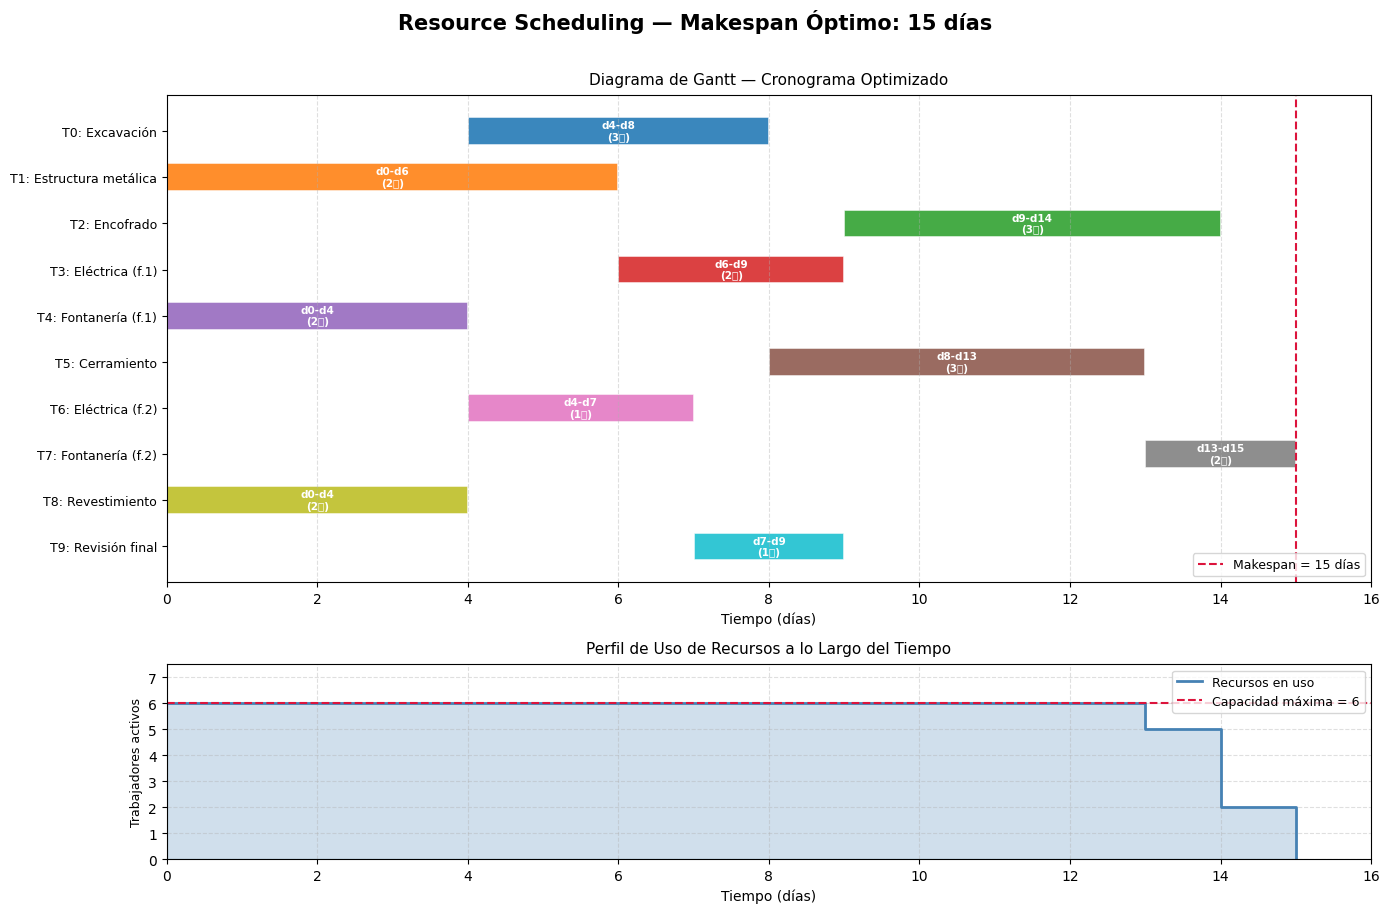

 Gráfico guardado como 'gantt_resource_scheduling.png'


In [ ]:
# ─────────────────────────────────────────────
# Visualización del cronograma y perfil de recursos
# ─────────────────────────────────────────────
if results is not None:

    # Paleta de colores para las tareas
    colors = plt.cm.tab10(np.linspace(0, 1, num_tasks))

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(14, 9),
        gridspec_kw={"height_ratios": [3, 1.2]}
    )
    fig.suptitle(
        f"Resource Scheduling — Makespan Óptimo: {int(optimal_makespan)} días",
        fontsize=15, fontweight="bold", y=1.01
    )

    # ─── Gráfico 1: Diagrama de Gantt ───────────────────────────────────────
    for i, r in enumerate(results):
        ax1.barh(
            y=i,
            width=r["Duración"],
            left=r["Inicio (día)"],
            color=colors[i],
            edgecolor="white",
            linewidth=1.2,
            height=0.6,
            alpha=0.88
        )
        # Etiqueta con inicio, fin y trabajadores
        ax1.text(
            r["Inicio (día)"] + r["Duración"] / 2,
            i,
            f"d{r['Inicio (día)']}-d{r['Fin (día)']}\n({r['Trabajadores']}👷)",
            ha="center", va="center",
            fontsize=7.5, fontweight="bold", color="white"
        )

    ax1.set_yticks(range(num_tasks))
    ax1.set_yticklabels(task_names, fontsize=9)
    ax1.set_xlabel("Tiempo (días)", fontsize=10)
    ax1.set_title("Diagrama de Gantt — Cronograma Optimizado", fontsize=11, pad=8)
    ax1.set_xlim(0, int(optimal_makespan) + 1)
    ax1.grid(axis="x", linestyle="--", alpha=0.4)
    ax1.invert_yaxis()  # La tarea 0 arriba

    # Línea vertical de makespan
    ax1.axvline(
        x=int(optimal_makespan), color="crimson",
        linestyle="--", linewidth=1.5, label=f"Makespan = {int(optimal_makespan)} días"
    )
    ax1.legend(loc="lower right", fontsize=9)

    # ─── Gráfico 2: Perfil de uso de recursos ────────────────────────────────
    time_axis = range(int(optimal_makespan))
    resource_profile = [
        sum(
            resources[i]
            for i in range(num_tasks)
            if results[i]["Inicio (día)"] <= t < results[i]["Fin (día)"]
        )
        for t in time_axis
    ]

    ax2.step(
        list(time_axis) + [int(optimal_makespan)],
        resource_profile + [0],
        where="post",
        color="steelblue", linewidth=2, label="Recursos en uso"
    )
    ax2.fill_between(
        list(time_axis) + [int(optimal_makespan)],
        resource_profile + [0],
        step="post", alpha=0.25, color="steelblue"
    )

    # Línea de capacidad máxima
    ax2.axhline(
        y=CAPACITY, color="crimson",
        linestyle="--", linewidth=1.5, label=f"Capacidad máxima = {CAPACITY}"
    )

    ax2.set_xlabel("Tiempo (días)", fontsize=10)
    ax2.set_ylabel("Trabajadores activos", fontsize=9)
    ax2.set_title("Perfil de Uso de Recursos a lo Largo del Tiempo", fontsize=11, pad=8)
    ax2.set_xlim(0, int(optimal_makespan) + 1)
    ax2.set_ylim(0, CAPACITY + 1.5)
    ax2.set_yticks(range(CAPACITY + 2))
    ax2.grid(axis="both", linestyle="--", alpha=0.4)
    ax2.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.savefig("gantt_resource_scheduling.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" Gráfico guardado como 'gantt_resource_scheduling.png'")

---
## 6. Análisis de Sensibilidad

¿Qué ocurre si modificamos la capacidad de recursos disponibles? A continuación se ejecuta el modelo para distintos valores de capacidad y se compara el makespan resultante.

Análisis de Sensibilidad — Makespan vs Capacidad:

 Capacidad (trabajadores) Makespan (días)
                        1      Infactible
                        2      Infactible
                        3              33
                        4              24
                        5              18
                        6              15
                        7              13
                        8              11
                        9              10
                       10               9


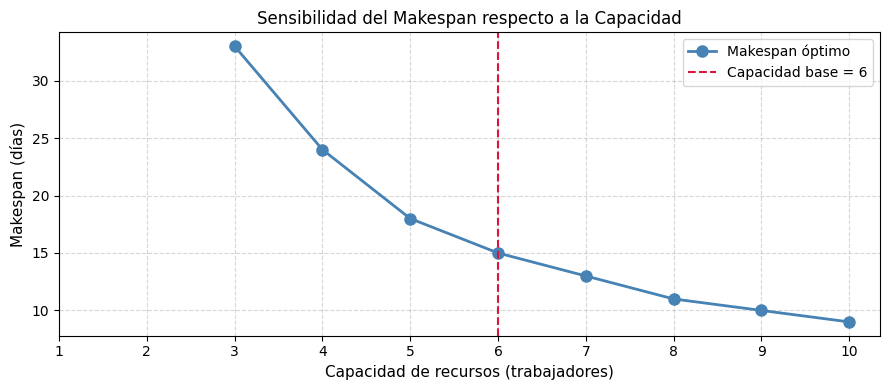

In [ ]:
# ─────────────────────────────────────────────
# Análisis de sensibilidad: makespan vs capacidad
# ─────────────────────────────────────────────

def solve_scheduling(capacidad):
    """Resuelve el modelo de scheduling para una capacidad dada.
    Devuelve el makespan óptimo o None si es infactible."""
    m = cp_model.CpModel()
    h = sum(durations)
    ivars, evars = [], []

    for i in range(num_tasks):
        sv = m.NewIntVar(0, h, f"s_{i}")
        ev = m.NewIntVar(0, h, f"e_{i}")
        iv = m.NewIntervalVar(sv, durations[i], ev, f"iv_{i}")
        ivars.append(iv)
        evars.append(ev)

    mk = m.NewIntVar(0, h, "mk")
    for ev in evars:
        m.Add(mk >= ev)

    m.AddCumulative(ivars, resources, capacidad)
    m.Minimize(mk)

    s = cp_model.CpSolver()
    s.parameters.max_time_in_seconds = 10.0
    s.parameters.log_search_progress = False
    st = s.Solve(m)

    if st in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return int(s.ObjectiveValue())
    return None


# Probar capacidades de 1 a 10
capacidades = list(range(1, 11))
makespans   = [solve_scheduling(c) for c in capacidades]

# Mostrar tabla de resultados
df_sens = pd.DataFrame({
    "Capacidad (trabajadores)": capacidades,
    "Makespan (días)":          [m if m else "Infactible" for m in makespans]
})
print("Análisis de Sensibilidad — Makespan vs Capacidad:\n")
print(df_sens.to_string(index=False))

# Gráfico de sensibilidad
valid = [(c, m) for c, m in zip(capacidades, makespans) if m is not None]
if valid:
    cap_vals, mk_vals = zip(*valid)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(cap_vals, mk_vals, marker="o", color="steelblue",
            linewidth=2, markersize=8, label="Makespan óptimo")
    ax.axvline(x=CAPACITY, color="crimson", linestyle="--",
               linewidth=1.5, label=f"Capacidad base = {CAPACITY}")
    ax.set_xlabel("Capacidad de recursos (trabajadores)", fontsize=11)
    ax.set_ylabel("Makespan (días)", fontsize=11)
    ax.set_title("Sensibilidad del Makespan respecto a la Capacidad", fontsize=12)
    ax.set_xticks(capacidades)
    ax.grid(linestyle="--", alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 7. Conclusiones

### Logros del Modelo

En este notebook hemos demostrado cómo **Google OR-Tools CP-SAT** puede resolver eficientemente un problema de *resource scheduling* con las siguientes características:

1. **Modelado formal:** Transformamos un problema real de planificación en un CSP con variables de intervalo y la restricción global `AddCumulative`.

2. **Optimización global:** El solver encontró el **makespan óptimo** — el cronograma más corto posible que respeta en todo instante la capacidad máxima de recursos.

3. **Verificación automática:** Comprobamos programáticamente que la solución no viola la restricción cumulative en ningún instante de tiempo.

4. **Análisis de sensibilidad:** Observamos cómo el makespan disminuye al aumentar la capacidad, con rendimientos decrecientes a partir de cierto punto.

### Posibles Extensiones del Modelo

| Extensión | Descripción |
|-----------|-------------|
| **Precedencias** | Añadir restricciones `AddNoOverlap2D` o `Add(start_j >= end_i)` para modelar dependencias entre tareas |
| **Múltiples recursos** | Usar varias restricciones `AddCumulative` (e.g., mano de obra + maquinaria + presupuesto) |
| **Tareas opcionales** | Usar `NewOptionalIntervalVar` para tareas que pueden ser omitidas o asignadas condicionalmente |
| **Ventanas de tiempo** | Añadir `model.Add(start_i >= release_i)` y `model.Add(end_i <= deadline_i)` |
| **Multi-objetivo** | Minimizar makespan + costes de penalización por retraso usando `model.Minimize(makespan + penalties)` |
| **Incertidumbre** | Modelar duraciones estocásticas mediante robust CP o escenarios Monte Carlo |
